# SWYNEX Final Data Analytics Project

## Online Retail Sales Analysis

### Project Overview
This project presents a complete data analytics case study using an Online Retail dataset. The objective is to clean and analyze retail transaction data, identify important sales trends and customer patterns, and present the findings through an interactive Power BI dashboard.

### Objectives
- Clean and prepare the raw retail transaction data
- Explore sales, customers, products, and countries
- Identify important revenue and sales trends
- Analyze monthly and country-wise performance
- Identify high-value customers
- Develop a Power BI dashboard for interactive analysis
- Generate actionable business insights

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook
- Power BI
- GitHub

## 1. Dataset Information

The dataset contains transaction records from an online retail business.

### Main Columns

| Column | Description |
|---|---|
| InvoiceNo | Unique invoice number |
| StockCode | Product/item code |
| Description | Product description |
| Quantity | Number of items purchased |
| InvoiceDate | Date and time of transaction |
| UnitPrice | Price per item |
| CustomerID | Unique customer identifier |
| Country | Customer's country |

The dataset is used to understand sales performance, customer behavior, product transactions, and geographical sales patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (536529, 8)


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536529 entries, 0 to 536528
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536529 non-null  str    
 1   StockCode    536529 non-null  str    
 2   Description  536529 non-null  str    
 3   Quantity     536529 non-null  int64  
 4   InvoiceDate  536529 non-null  str    
 5   UnitPrice    536529 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536529 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 32.7 MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,536529.000000,536529.000000,401604.000000
mean,9.623748,4.633623,15281.160818
std,219.152755,97.243243,1714.006089
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13939.000000
50%,3.000000,2.080000,15145.000000
75%,10.000000,4.130000,16784.000000
max,80995.000000,38970.000000,18287.000000


## 2. Data Cleaning & Preparation

The raw Online Retail dataset was cleaned before performing the analysis.

The main data preparation steps included:

- Removing duplicate transaction records
- Cleaning unnecessary spaces from text fields
- Handling missing values in the `Description` column
- Reviewing missing values in the `CustomerID` column
- Checking negative and zero values in `Quantity`
- Checking negative and zero values in `UnitPrice`
- Reviewing cancelled transactions using `InvoiceNo`
- Verifying the final dataset structure and data types

After cleaning, the dataset contained **536,529 records and 8 columns**.

The `CustomerID` column still contains some missing values because customer information was not available for all transactions. These records were retained where appropriate for transaction-level sales analysis.

In [6]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134925
Country             0
dtype: int64


In [7]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [8]:
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())
print("Negative UnitPrice:", (df["UnitPrice"] < 0).sum())
print("Zero UnitPrice:", (df["UnitPrice"] == 0).sum())

Negative Quantity: 10490
Zero Quantity: 0
Negative UnitPrice: 2
Zero UnitPrice: 2398


## 3. Revenue Analysis

Revenue was calculated by multiplying the quantity of each transaction by its unit price.

This metric helps measure the financial contribution of individual transactions and identify important sales trends.

In [9]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print("Revenue column created successfully.")
df[["Quantity", "UnitPrice", "Revenue"]].head()

Revenue column created successfully.


,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [10]:
total_revenue = df["Revenue"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 9,726,006.95


## 4. Sales Trend Analysis

The transaction date was converted into a proper datetime format to analyze revenue trends over time.

Monthly revenue was then calculated to identify periods of higher and lower sales performance.

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

print("InvoiceDate converted successfully.")
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

InvoiceDate converted successfully.
2010-12-01 08:26:00
2011-12-09 12:50:00


In [12]:
monthly_revenue = df.groupby("YearMonth")["Revenue"].sum().sort_values(ascending=False)

print("Top 5 months by revenue:")
print(monthly_revenue.head())

Top 5 months by revenue:
YearMonth
2011-11    1456145.800
2011-10    1069368.230
2011-09    1017596.682
2010-12     746723.610
2011-05     722094.100
Name: Revenue, dtype: float64


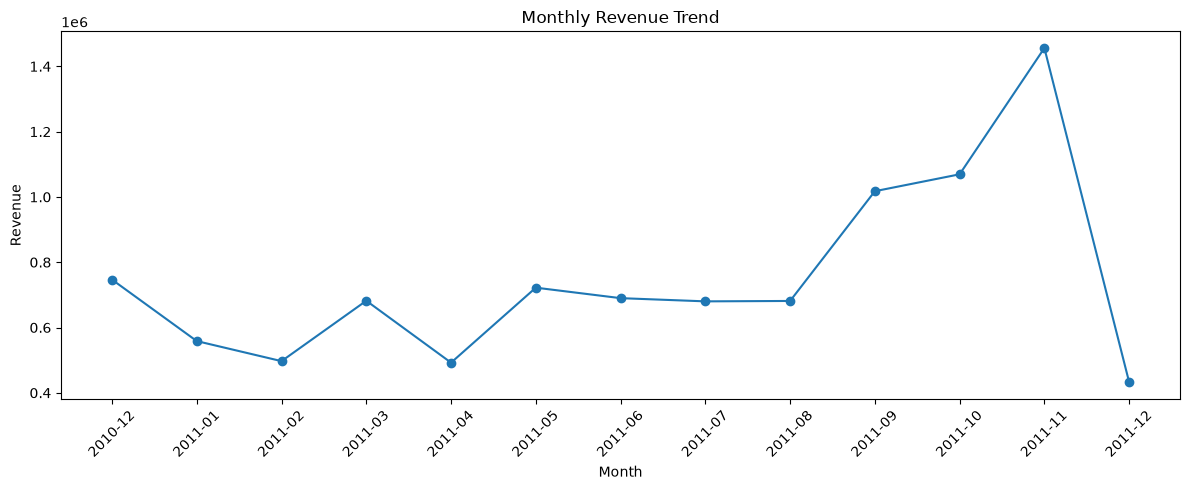

In [13]:
monthly_revenue_sorted = monthly_revenue.sort_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue_sorted.index, monthly_revenue_sorted.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Country-wise Sales Analysis

Country-level analysis was performed to understand the geographical distribution of sales and identify the markets contributing the most revenue.

In [14]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 countries by revenue:")
print(country_revenue.head(10))

Top 10 countries by revenue:
Country
United Kingdom    8167128.184
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64


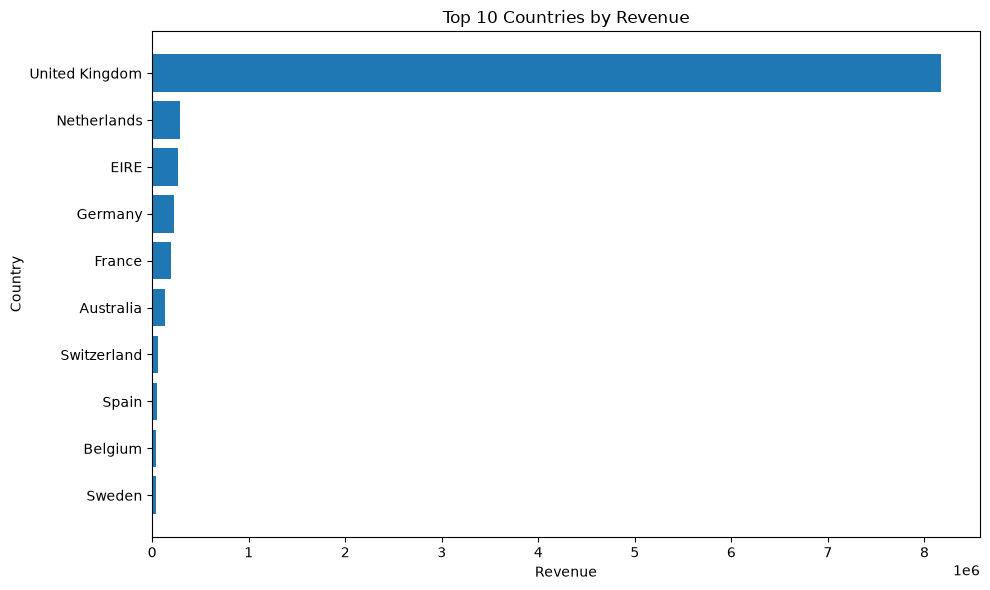

In [15]:
top_10_countries = country_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_10_countries.index, top_10_countries.values)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## 6. Customer Analysis

Customer-level revenue was analyzed to identify customers who contributed significantly to overall sales.

In [16]:
customer_revenue = (
    df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 customers by revenue:")
print(customer_revenue.head(10))

Top 10 customers by revenue:
CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64


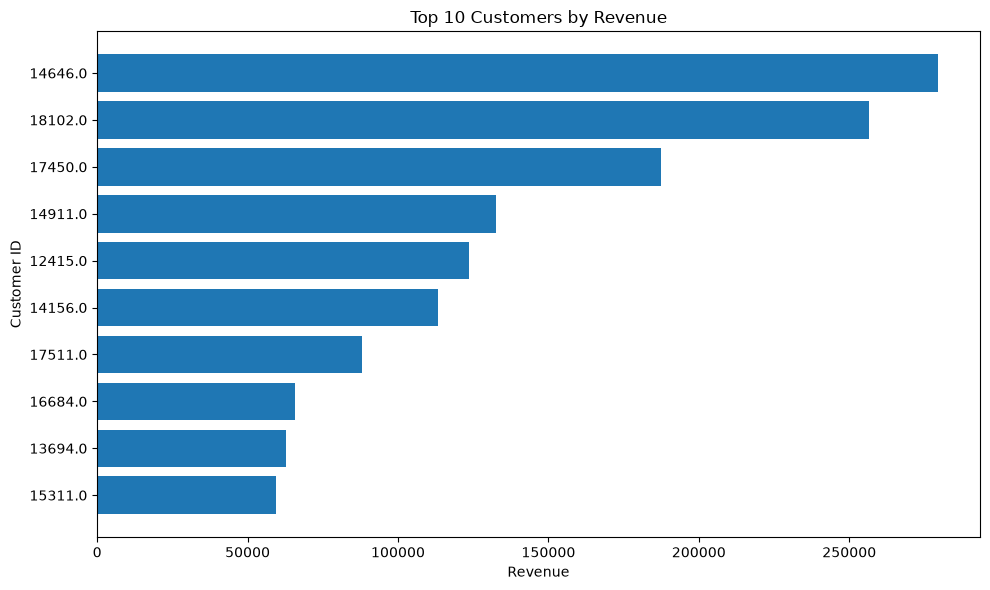

In [17]:
top_customers = customer_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_customers.index.astype(str), top_customers.values)
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

## 7. Key Business Insights

The analysis of the Online Retail dataset revealed several important business patterns:

### 1. Overall Sales
The dataset generated approximately **9.73 million** in total transaction revenue when returns and negative transactions are included.

### 2. Monthly Performance
**November 2011** recorded the highest monthly revenue in the analysis, indicating a strong sales period toward the end of the year.

### 3. Geographical Performance
The **United Kingdom** generated the highest revenue among the countries in the dataset, making it the largest market in this analysis.

### 4. Customer Contribution
Customer **14646** generated the highest customer-level revenue, contributing approximately **280,206**.

### 5. Returns and Cancellations
Negative quantities and cancelled invoices were present in the dataset. These transactions are important because they affect the net revenue and provide information about product returns and cancellations.

### 6. Data Quality
The final cleaned dataset contained **536,529 rows and 8 columns**, with duplicate records removed and missing product descriptions handled during the cleaning process.

## 8. Interactive Power BI Dashboard

An interactive Power BI dashboard was developed to present the major findings from the analysis in an easy-to-understand visual format.

The dashboard includes:

- Revenue KPIs
- Sales trends
- Country-wise performance
- Customer analysis
- Interactive filters
- Visual summaries of key business metrics

The dashboard allows users to explore the retail data interactively and identify important sales patterns.

### Dashboard Preview

The Power BI dashboard developed during Task 3 is included in the `dashboard` folder of this project.

## 9. Conclusion

This project provided an end-to-end data analytics workflow using an Online Retail dataset.

The process included data cleaning, exploratory data analysis, revenue analysis, customer analysis, geographical analysis, and dashboard development.

Python and Pandas were used for data preparation and analysis, while Power BI was used to create an interactive dashboard for visual exploration.

The analysis highlighted important sales trends, major markets, and high-value customers. These findings can help businesses understand their sales performance and identify areas that require further analysis.

Overall, this project demonstrates the complete workflow of a data analytics case study, from raw data preparation to business insights and visualization.

## 10. Skills & Learning Outcomes

Through this project, I gained practical experience in:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Pandas and NumPy
- Data visualization with Matplotlib
- Revenue and customer analysis
- Handling real-world transaction data
- Power BI dashboard development
- Extracting business insights from data
- Documenting and presenting an analytics project
- Using GitHub for project management and sharing